In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


from osa import OSA
import time
import numpy as np
import matplotlib.pyplot as plt
import wshelper as wsh
import calibration
from wsapi import * 
from scipy.signal import find_peaks


def create_connect_waveshaper():
    wsh.createWS('./WS200224_4x16.wsconfig')
    wsh.connect()

def disconnect_delete_waveshaper():
    wsh.disconnect()
    wsh.deleteWS()

def apply_waveshaper_profile(comblines, peaks, phases, channels, delta_l=0.1, sigma=0.005, plot = False):
    """
    Function to apply a waveshaper profile based on the input parameters.

    Parameters:
    - comblines: List of center frequencies for the Gaussian signals.
    - peaks: List of peak amplitudes for the Gaussian signals.
    - phases: List of phases for the Gaussian signals.
    - channels: List of channel assignments for each signal.
    - delta_l: Offset for frequency range. Default is 0.4.
    - sigma: Standard deviation for Gaussian function. Default is 0.008.
    """
    
    # Step 1: Precompute THz values for comblines and precompute bounds for each combline
    combline_thz = [wsh.nm2thz(combline) for combline in comblines] 
    rang_min = [wsh.nm2thz(combline - delta_l) for combline in comblines]
    rang_max = [wsh.nm2thz(combline + delta_l) for combline in comblines]
    
    # Step 2: Calculate the overall frequency range in THz only once
    rang = (wsh.nm2thz(min(comblines)-0.3), wsh.nm2thz(max(comblines)+0.3))
    rang = (round(rang[0], 3), round(rang[1], 3))

    # Step 3: Generate the signal profile for each combline
    signal = tuple(
        wsh.BoundFunc(
            wsh.gaussian(mu=comb_thz, peak=peak, phase=phase, sigma=sigma),
            max_r, min_r, channel
        )
        for comb_thz, peak, phase, channel, min_r, max_r 
        in zip(combline_thz, peaks, phases, channels, rang_min, rang_max)
    )
    #print(f'the peaks are: {peaks}')
    
    # Step 4: Compose the profile
    new_profile = wsh.compose_func((0, 0, 0), rang[1], rang[0], 1e-3, *signal)
    
    # Step 5: Plot the generated attenuation profile
    if plot == True:        
        plt.plot(wsh.nm2thz(new_profile[:, 0]), -new_profile[:, 1])
        plt.xlabel('Wavelength (nm)')
        plt.ylabel('Attenuation')
        plt.title('Generated Profile')
        plt.show()

    wsh.apply_profile(new_profile)

    # Step 6: Apply missagh profile to waveshaper
    # gaussian_wave = wsh.gaussian(mu=wsh.nm2thz(1552.4), peak=1, phase=0, sigma=0.4)  
    # bound_gaussian = wsh.BoundFunc(gaussian_wave, wsh.nm2thz(1553.8), wsh.nm2thz(1551), 8)
    # missagh_profile = wsh.compose_func((0, 0, 0), wsh.nm2thz(1553.8), wsh.nm2thz(1551), 1e-3, bound_gaussian)
    # wsh.apply_profile(missagh_profile)  

class CustomLayer(nn.Module):
    def __init__(self, comblines):
        super(CustomLayer, self).__init__()
        # Initialize k as a trainable parameter with the same size as C
        self.phi = nn.Parameter(torch.zeros(len(comblines)))

    def forward(self, C):
        return self.physical_model(self.phi, C)
    
    def physical_model(self, phases, coefficients):
        N = coefficients.size(1)
        z = 1
        zero_tensor = torch.full((coefficients.size(0), 1), float(0), dtype=coefficients.dtype, device=coefficients.device)
        C = torch.cat((zero_tensor, coefficients), dim=1)

        k = torch.cat((torch.tensor([float(0)], dtype=phases.dtype, device=phases.device), phases))

        # Preallocate intensity tensor
        intensity = torch.zeros((coefficients.size(0), 2 * N + 1), dtype=torch.float, device=C.device)

        # Use vectorized operations where possible
        m_range = [torch.full((N-1, N-1), i, device=C.device) for i in torch.arange(2, 2 * N + 1)]
        # Separate odd and even tensors based on the integer value inside the tensor
        odd_m = [m for m in m_range if m[0, 0].item() % 2 == 1]
        even_m = [m for m in m_range if m[0, 0].item() % 2 == 0]

        js, ls = torch.meshgrid(torch.arange(1, N, device=C.device), torch.arange(1, N, device=C.device), indexing='ij')
        for m in odd_m:

            valid_indices = (0 < m - js) & (m - js <= N) & (0 < m - ls) & (m - ls <= N)

            j, l, m = js[valid_indices], ls[valid_indices], m[valid_indices]

            term = 4 * C[:, j] * C[:, m - j] * C[:, l] * C[:, m - l] * torch.exp(1j * (k[j] + k[m - j] - k[l] - k[m - l]) * z)
            intensity[:, m[0]] = term.sum(dim=1)
            #torch.cuda.memory._dump_snapshot("my_snapshot.pickle")

        for m in even_m:
            if m[0, 0] == 2 or m[0, 0] == 2 * N:
                intensity[:, m[0, 0]] = C[:, m[0, 0] // 2] ** 4
            else:
                valid_indices = (0 < m - js) & (m - js <= N) & (0 < m - ls) & (m - ls <= N)

                j, l, m = js[valid_indices], ls[valid_indices], m[valid_indices]

                exp_term = torch.exp(1j * (k[j] + k[m - j]) * z)
                middle_term = C[:, m // 2] ** 2 * torch.exp(1j * 2 * k[m // 2] * z)

                term1 = (2 * C[:, j] * C[:, m - j] * exp_term + middle_term).sum(dim=1)
                term2 = (2 * C[:, l] * C[:, m - l] * exp_term.conj() + middle_term.conj()).sum(dim=1)

                intensity[:, m[0]] = (term1 * term2).real
        
        return torch.abs(intensity[:, 2:2 * N + 1])


import os 

def create_folders(name):
    base_path = os.path.join("data_runs", name)
    stability_path = os.path.join(base_path, "stability")
    checkpoints_path = os.path.join(base_path, "checkpoints")
    traces_path = os.path.join(base_path, "traces")

    os.makedirs(stability_path, exist_ok=True)
    os.makedirs(checkpoints_path, exist_ok=True)
    os.makedirs(traces_path, exist_ok=True)

    print(f"Folders ensured:\n- {stability_path}\n- {checkpoints_path}\n- {traces_path}")


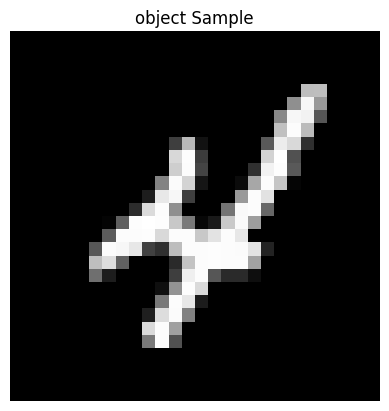

In [10]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from skimage.filters import threshold_otsu


IMAGE_SIZE = 28  # Fashion MNIST image size (28x28)

# Custom transformation that applies Otsu's thresholding
class OtsuBinarize(object):
    def __call__(self, image):
        image_np = image.squeeze().numpy()
        thresh = threshold_otsu(image_np)
        binary_np = (image_np > thresh).astype(np.float32)
        return torch.from_numpy(binary_np).unsqueeze(0)

# Define the transformation pipeline
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=transforms.InterpolationMode.NEAREST) #OtsuBinarize(),transforms.Normalize(mean=[0.5], std=[0.5])
])

#train_dataset = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
# Get indices for samples with label 4 ("object")
object_indices = [i for i, (_, label) in enumerate(train_dataset) if label == 3 or label == 4]

# Specify the number of object samples you want
n = 20#40  # replace with any number you desire

# Select the first n object indices
selected_object_indices = object_indices[:n]

# Create a subset of the dataset containing only the selected objects
object_dataset = Subset(train_dataset, selected_object_indices)

# Optionally, create a DataLoader for the subset
train_loader = DataLoader(object_dataset, batch_size=1, shuffle=True)

# Now, train_loader will yield batches containing only object images.

import matplotlib.pyplot as plt

# Extract one sample from the object_dataset
sample, label = object_dataset[2]

# Display the image
plt.imshow(sample.squeeze(), cmap='gray')
plt.title("object Sample")
plt.axis("off")
plt.show()


192.168.10.85 is reachable, Connected to OSA
Successfully login!
Creating waveshaper...   success
Connecting to waveshaper...   success
Applying profile...   success
Applying profile...   success
Sweep complete.


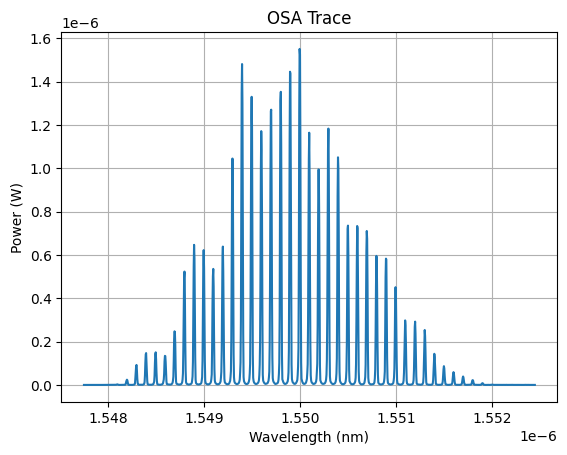

Sweep complete.
the power is 776


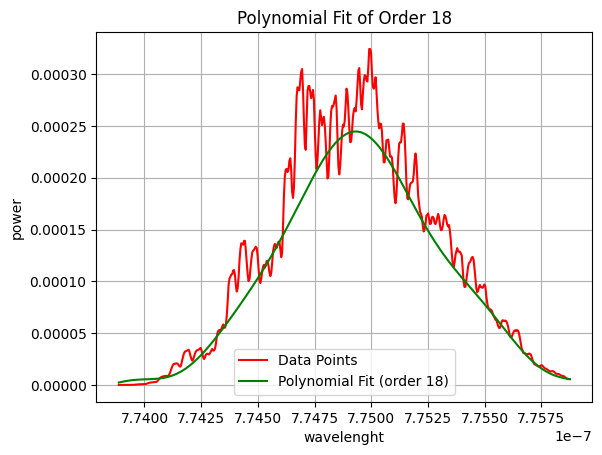

number of maximum points 52
-27.441837919889696


Text(0, 0.5, 'Amplitude')

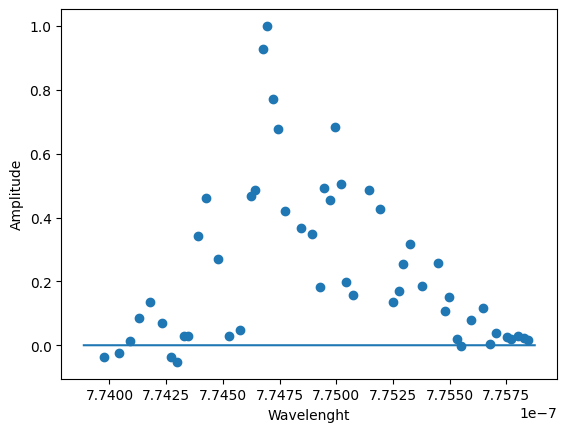

In [11]:
# Connecting to the OSA and Waveshaper, verifying correct behaviour
from pat import make_pat_func

# === Instantiate and connect OSA ===
host = '192.168.10.85'  # OSA IP address
port = 10001            # OSA port number
osa = OSA(host, port)
osa.connect()
response = osa.autenticate()
create_connect_waveshaper()

n_comblines = 21
separation_comblines = 0.2
initial_wl = 1549.598-separation_comblines*8
# === Calibrate ===
comblines = np.arange(initial_wl, initial_wl + n_comblines * separation_comblines, separation_comblines)
peaks = np.ones(n_comblines)
phases = np.zeros(n_comblines)
channels = np.ones(n_comblines)
apply_waveshaper_profile(comblines, phases, phases, channels, plot = False)
apply_waveshaper_profile(comblines, peaks, phases, channels, plot = False)
wavelengths, power = osa.perform_measurement_OSA(np.mean(comblines), (np.max(comblines)-np.mean(comblines))*2+0.5, 0.02, sensitivity = "high3", resolution = 0.02)
osa.plot_trace(wavelengths, power)

# Perform calibration
order = 18
wavelength, power, poly = calibration.do_calibration(osa, center=np.mean(comblines)/2-0.1, span=(np.max(comblines)-np.mean(comblines))+1, order = order, level=2, spacing='lin')
print(f'the power is {len(power)}')
powerfit = poly(wavelength)
initrang = 122
finrang = 620
calibration.plot_polynomial_fit(wavelength[initrang:finrang], power[initrang:finrang], wavelength[initrang:finrang], powerfit[initrang:finrang], order=order)

prominence = power - powerfit
prominence_trim = prominence[initrang:finrang]
wavelength_trim = wavelength[initrang:finrang]
max_indices, _ = find_peaks(prominence_trim, distance=5, prominence=1e-8)
print(f'number of maximum points {len(max_indices)}')
max_x = np.array(wavelength_trim)[max_indices]
max_y = np.array(prominence_trim)[max_indices]

fraction_max_min = np.max(max_y)/(max_y[0])
normalization = 1/(fraction_max_min*max_y[0])
print(fraction_max_min)
plt.plot(wavelength_trim,prominence_trim)
plt.scatter(max_x, normalization*max_y)
plt.xlabel('Wavelenght')
plt.ylabel('Amplitude')

In [12]:
# Waveshaper layer
comblines = n_comblines
#max_indices = np.arange(11,29*12,12)
def lambda_m(lambda_1, delta_lambda, m):
    return 1 / ((2 / lambda_1) - (m - 1) * (abs(delta_lambda) / lambda_1**2))

# Example usage
lambda_1 = initial_wl  # Example value in nm
delta_lambda = separation_comblines  # Example value in nm
m = np.arange(1,2*comblines,1)  # Example mode number

targets = lambda_m(lambda_1, delta_lambda, m)* 1e-9
print(f"λ_m = {targets}")

wavelengths_nm = wavelength_trim 
max_indices = [np.argmin(np.abs(wavelengths_nm - t)) for t in targets]
print(f"Indices {max_indices}")

class WaveshaperLayer(nn.Module):
    def __init__(self, osa, comblines, channels, baseline, normalization, delta_l=0.1, sigma=0.005):
        super(WaveshaperLayer, self).__init__()
        
        self.osa = osa
        self.comblines = comblines
        self.channels = channels
        self.baseline = baseline
        self.normalization = normalization
        self.delta_l = delta_l
        self.sigma = sigma
        
        # Convert comblines to THz
        self.combline_thz = [wsh.nm2thz(combline) for combline in self.comblines]
        self.rang_min = [wsh.nm2thz(combline - delta_l) for combline in self.comblines]
        self.rang_max = [wsh.nm2thz(combline + delta_l) for combline in self.comblines]
        
        # Trainable phases
        self.phases = nn.Parameter(torch.zeros(len(comblines)))
        
    def forward(self, peaks):
        # Convert self.phases (tensor) to a NumPy array
        phases_slice = self.phases[:peaks.shape[0]]   
        phases_expressiveness = torch.dot(phases_slice, peaks)
        phases_np = self.phases.cpu().numpy() if torch.is_tensor(phases_expressiveness) else phases_expressiveness
        phase = phases_np
    
        # Generate signal profile for each combline
        apply_waveshaper_profile(self.comblines, peaks, phase, self.channels)

        wavelength, measurement = self.osa.perform_measurement_OSA(center=np.mean(self.comblines)/2-0.1, span=(np.max(comblines)-np.mean(comblines))+1, level=0.006, sensitivity = "high1", resolution = 0.02)
        # Use scipy's find_peaks to find local maxima in the inverted signal (i.e., local minima in original)
        prominence = measurement - self.baseline(wavelength)
        prominence = calibration.set_measurement_outside_range_to_zero(wavelength, prominence, (np.min(self.comblines)/2-0.3)*1e-9, (np.max(self.comblines)/2+0.3)*1e-9)
        prominence_trim = prominence[initrang:finrang]
        
        max_y = np.array(prominence_trim)[max_indices]
        max_y = max_y/(max_y[0]*self.normalization)
        # Convert max_y (NumPy array) back to a tensor
        max_y_tensor = torch.tensor(max_y, dtype=torch.float32)
        
        return max_y_tensor
    

λ_m = [7.73999000e-07 7.74049003e-07 7.74099013e-07 7.74149029e-07
 7.74199052e-07 7.74249081e-07 7.74299116e-07 7.74349158e-07
 7.74399207e-07 7.74449262e-07 7.74499323e-07 7.74549391e-07
 7.74599465e-07 7.74649546e-07 7.74699634e-07 7.74749727e-07
 7.74799828e-07 7.74849934e-07 7.74900048e-07 7.74950167e-07
 7.75000294e-07 7.75050426e-07 7.75100566e-07 7.75150711e-07
 7.75200863e-07 7.75251022e-07 7.75301187e-07 7.75351359e-07
 7.75401537e-07 7.75451722e-07 7.75501913e-07 7.75552110e-07
 7.75602314e-07 7.75652525e-07 7.75702742e-07 7.75752966e-07
 7.75803196e-07 7.75853432e-07 7.75903676e-07 7.75953925e-07
 7.76004181e-07]
Indices [np.int64(28), np.int64(41), np.int64(53), np.int64(66), np.int64(78), np.int64(91), np.int64(103), np.int64(116), np.int64(128), np.int64(141), np.int64(153), np.int64(166), np.int64(178), np.int64(191), np.int64(203), np.int64(216), np.int64(228), np.int64(241), np.int64(253), np.int64(266), np.int64(278), np.int64(291), np.int64(303), np.int64(316), np.i

In [13]:
comblines = np.arange(initial_wl, initial_wl + n_comblines * separation_comblines, separation_comblines)
channels = np.ones(n_comblines)

physical_reality = WaveshaperLayer(osa, comblines=comblines, channels=channels, baseline=poly, normalization=fraction_max_min)
physical_model = CustomLayer(comblines=comblines)

pat_implementation = make_pat_func(physical_reality.forward, physical_model.forward)

LEARNING_RATE = 1e-3
EPOCHS = 190
LATENT_DIM = n_comblines  # Latent space dimension
INPUT_DIM = IMAGE_SIZE * IMAGE_SIZE  # Flattened image dimension
HIDDEN_DIM =  2*LATENT_DIM-1 # Hidden layer dimension

class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        # Encoder
        self.fc1 = nn.Linear(INPUT_DIM, HIDDEN_DIM)  # First fully connected layer
        self.fc_mu = nn.Linear(HIDDEN_DIM, LATENT_DIM)  # Mean for the latent variable
        self.fc_logvar = nn.Linear(HIDDEN_DIM, LATENT_DIM)  # Log variance for the latent variable
        
        # Decoder
        self.fc2 = nn.Linear(LATENT_DIM, HIDDEN_DIM)  # Fully connected layer in decoder
        self.fc3 = nn.Linear(HIDDEN_DIM, INPUT_DIM)  # Output layer (reconstructs the image)
        
    def encode(self, x):
        h1 = torch.relu(self.fc1(x))
        mu = self.fc_mu(h1)
        logvar = self.fc_logvar(h1)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)  # Compute standard deviation
        eps = torch.randn_like(std)  # Sample epsilon from N(0, 1)
        return mu + eps * std  # Reparameterization trick
    
    def decode(self, z):
        z = torch.cat([torch.tensor([z[0][i]]) for i in range(len(z[0]))], dim=0)
        h2 = pat_implementation(z)
        return torch.sigmoid(self.fc3(h2))  # Sigmoid to ensure the output is between 0 and 1
    
    def forward(self, x):
        mu, logvar = self.encode(x.view(x.size(0), -1))  # Encode the input
        z = self.reparameterize(mu, logvar)  # Reparameterization step
        #print(f'The shape of input of decode is {z.shape}')
        return self.decode(z), mu, logvar  # Decode the latent variable and return

# 4. Loss Function (VAE Loss: Reconstruction + KL Divergence)
def vae_loss(recon_x, x, mu, logvar):
    x = x.view(x.size(0), -1)
    x = x.squeeze()
    BCE = nn.functional.binary_cross_entropy(recon_x.view(recon_x.size(0),-1), x.view(x.size(0), -1), reduction='sum')
    # KL Divergence
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD







In [ ]:
name_of_experiment = "experiment_VAE_02"  # Replace with your desired folder name
create_folders(name_of_experiment)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def train(model, train_loader, optimizer, epoch, loss_history):
    model.train()
    train_loss = 0
    for data in train_loader:
        data, _ = data
        #print(data)
        recon_batch, mu, logvar = model(data)
        loss = vae_loss(recon_batch, data, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    avg_epoch_loss = train_loss / len(train_loader.dataset)
    loss_history.append(avg_epoch_loss)  # Store the average loss in the history

        
interval_images = 1

model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

import pandas as pd  # For saving data to CSV

loss_history = []

for epoch in range(EPOCHS):
    train(model, train_loader, optimizer, epoch, loss_history)
    avg_loss = loss_history[-1]  # Get the most recent average loss
    print(f"Epoch {epoch + 1}/{EPOCHS}, Loss: {avg_loss:.4f}")
    
    # Stop training if the loss is below the threshold
    if avg_loss < 0.01:
        print(f"Stopping early at epoch {epoch + 1} as loss < 0.001")
        break

    # Save checkpoint after each epoch (optional)
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': avg_loss
    }
    torch.save(checkpoint, f'./data_runs/{name_of_experiment}/checkpoints/model_checkpoint{epoch}.pth')

# Plot the loss over epochs
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.show()

Folders ensured:
- data_runs\experiment_VAE_02\stability
- data_runs\experiment_VAE_02\checkpoints
- data_runs\experiment_VAE_02\traces
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep 

Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.


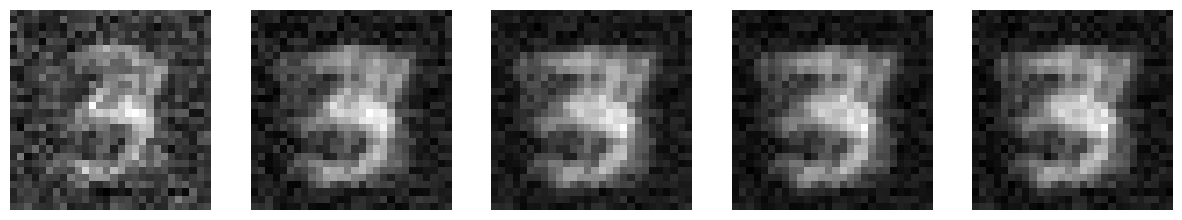

In [ ]:
def generate_images(model, number_of_images):
    model.eval()
    samples_new = []

    with torch.no_grad():
        for i in range(number_of_images):
            z = torch.randn(1, LATENT_DIM).to(device)  # Sample random latent variables
            sample = model.decode(z).cpu()            # sample shape is [784]
            # If needed, unsqueeze to add a batch dimension, so sample becomes [1, 784]
            if sample.dim() == 1:
                sample = sample.unsqueeze(0)
            samples_new.append(sample)
    
    # Stack along the batch dimension (dim=0)
    samples_new = torch.stack(samples_new, dim=0)  # Now shape: [number_of_images, 1, 784]
    # Reshape each sample to [1, 28, 28]
    return samples_new.view(number_of_images, 1, IMAGE_SIZE, IMAGE_SIZE)

# Generate and visualize new images
number_of_images = 5
generated_images = generate_images(model, number_of_images)

# Plot the generated images
fig, axes = plt.subplots(1, number_of_images, figsize=(15, 5))
for i in range(number_of_images):
    axes[i].imshow(generated_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.savefig(f"./data_runs/{name_of_experiment}/new_image.png")

plt.show()


In [ ]:
# === Disconnect ===
disconnect_delete_waveshaper()
osa.close_connection()

Disconnecting from waveshaper...   success
Deliting waveshaper...   success
Connection closed
